In [ ]:
!pip install numpy scanpy squidpy scikit-learn pyAgrum matplotlib anndata

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 2.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 3.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.8/87.8 kB 3.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
INFO: pip is looking at multiple versions of spatialdata to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of spatialdata to determine which version is compatible with other requirements. This could take a while.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 3.1 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of dask[array,dataframe] to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of ome-zarr to determine which version is compatible with other requirements. This could take a 

<>:19: SyntaxWarning: invalid escape sequence '\m'
<>:20: SyntaxWarning: invalid escape sequence '\m'
<>:30: SyntaxWarning: invalid escape sequence '\m'
<>:31: SyntaxWarning: invalid escape sequence '\m'
<>:19: SyntaxWarning: invalid escape sequence '\m'
<>:20: SyntaxWarning: invalid escape sequence '\m'
<>:30: SyntaxWarning: invalid escape sequence '\m'
<>:31: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_4976/3922379754.py:19: SyntaxWarning: invalid escape sequence '\m'
  plt.xlabel("spatial1 ($\mu$m)")
/tmp/ipykernel_4976/3922379754.py:20: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel("spatial2 ($\mu$m)")
/tmp/ipykernel_4976/3922379754.py:30: SyntaxWarning: invalid escape sequence '\m'
  ax.set_xlabel("spatial1 ($\mu$m)")
/tmp/ipykernel_4976/3922379754.py:31: SyntaxWarning: invalid escape sequence '\m'
  ax.set_ylabel("spatial2 ($\mu$m)")


AnnData object with n_obs × n_vars = 7753 × 4624
    obs: 'cell_id', 'final_label'
    obsm: 'X_pca', 'signaling', 'spatial'


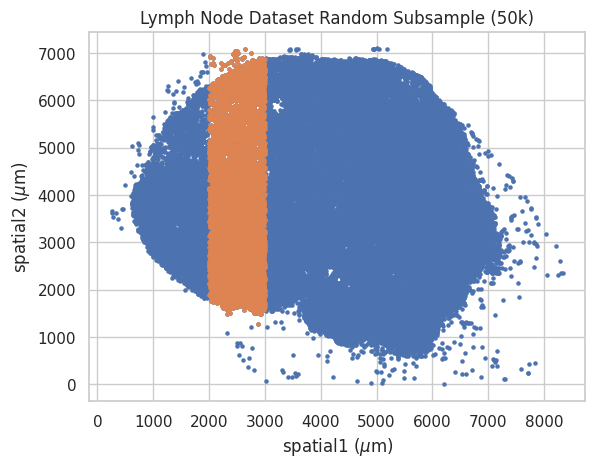

/tmp/ipykernel_4976/3922379754.py:28: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  ax = sc.pl.spatial(adata, color='final_label', spot_size=18, title="STHELAR Ground Truth",show=False)[0]


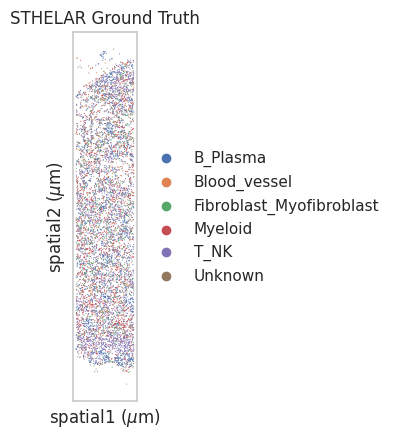

In [ ]:
import scanpy as sc
import squidpy as sq
from sklearn.mixture import GaussianMixture
import pyagrum
import numpy as np
import matplotlib.pyplot as plt
import anndata as ad
import seaborn as sns

sns.set_theme(style="whitegrid")

true_adata = sc.read_h5ad("lymph_node_50k_with_signaling_unscaled.h5ad")

coords = true_adata.obsm['spatial']
mask =  ((coords[:, 0] > 2000) & (coords[:, 0] < 3000))
mask &= ((coords[:, 1] > 0)    & (coords[:, 1] < 6000))
adata = true_adata[mask].copy()

plt.xlabel("spatial1 ($\mu$m)")
plt.ylabel("spatial2 ($\mu$m)")
plt.title("Lymph Node Dataset Random Subsample (50k)")

plt.scatter(coords[:, 0], -coords[:, 1] + coords[:, 1].max(), s=5)
plt.scatter(coords[mask, 0], -coords[mask, 1] + coords[:, 1].max(), s=5)
print(adata)
plt.show()

ax = sc.pl.spatial(adata, color='final_label', spot_size=18, title="STHELAR Ground Truth",show=False)[0]

ax.set_xlabel("spatial1 ($\mu$m)")
ax.set_ylabel("spatial2 ($\mu$m)")

# 3. Show the customized plot
plt.show()

In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

sq.gr.spatial_neighbors(adata, n_neighs=6, coord_type="generic")
A = adata.obsp["spatial_connectivities"].tocoo()
pairs = zip(A.row, A.col)
edges = [(i, j) for i, j in pairs if i < j]

n_nodes = adata.n_obs
X = np.log1p(adata.obsm["signaling"])
X = StandardScaler().fit_transform(X)

pca = PCA(n_components=min(20, X.shape[1]), random_state=0)
X_pca = pca.fit_transform(X)

K = 20 # number of niches to find
gmm = GaussianMixture(n_components=K, covariance_type="full", reg_covar=1e-5, random_state=0)
gmm.fit(X_pca)
Q = gmm.predict_proba(X_pca)

beta = 200
D_csr = adata.obsp["spatial_distances"].tocsr()
rows_arr = np.array([i for i, j in edges])
cols_arr = np.array([j for i, j in edges])
dist_values = np.asarray(D_csr[rows_arr, cols_arr]).flatten()
edge_weights = np.exp(beta * np.exp(-dist_values))

INFO     Creating graph using `generic` coordinates and `None` transform and `1` libraries.                        


<>:44: SyntaxWarning: invalid escape sequence '\m'
<>:45: SyntaxWarning: invalid escape sequence '\m'
<>:44: SyntaxWarning: invalid escape sequence '\m'
<>:45: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_4976/531661318.py:44: SyntaxWarning: invalid escape sequence '\m'
  ax.set_xlabel("spatial1 ($\mu$m)")
/tmp/ipykernel_4976/531661318.py:45: SyntaxWarning: invalid escape sequence '\m'
  ax.set_ylabel("spatial2 ($\mu$m)")


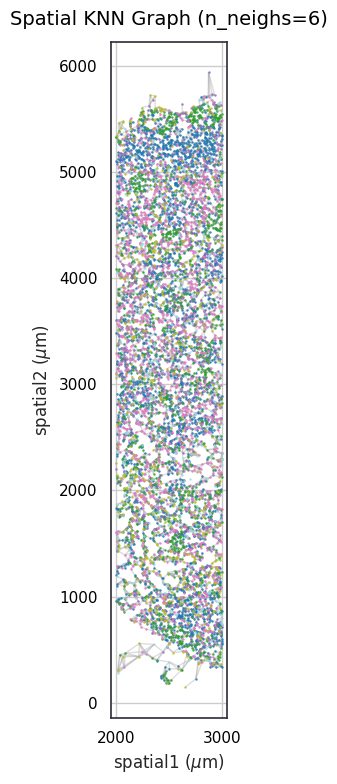

In [ ]:
import matplotlib.collections as mc

coords = adata.obsm["spatial"]
x, y = coords[:, 0], coords[:, 1]

adj = adata.obsp["spatial_connectivities"]
cx = adj.tocoo()

mask = cx.row < cx.col
rows = cx.row[mask]
cols = cx.col[mask]

segments = [
  [(x[i], y[i]), (x[j], y[j])]
  for i, j in zip(rows, cols)
]

fig, ax = plt.subplots(figsize=(10, 8), facecolor="#ffffff")
ax.set_facecolor("#ffffff")
ax.set_title("Spatial KNN Graph (n_neighs=6)", color="black", fontsize=14, pad=12)
ax.tick_params(colors="black")
for spine in ax.spines.values():
  spine.set_edgecolor("#333340")

lc = mc.LineCollection(segments,colors="#aaaaaa",linewidths=1,alpha=.4,zorder=1)
ax.add_collection(lc)

labels = adata.obs["final_label"]
categories = labels.unique()
cmap = plt.get_cmap("tab20", len(categories))
cat_to_idx = {c: i for i, c in enumerate(categories)}
node_colors = [cmap(cat_to_idx[l]) for l in labels]

for i, cat in enumerate(categories):
  mask_cat = labels == cat
  ax.scatter(x[mask_cat], y[mask_cat],s=3,c=[cmap(i)],alpha=.85,linewidths=0,label=str(cat),zorder=2)


ax.autoscale()
ax.set_aspect("equal")
ax.set_xlabel("spatial1 ($\mu$m)")
ax.set_ylabel("spatial2 ($\mu$m)")

plt.tight_layout()

plt.show()

<>:32: SyntaxWarning: invalid escape sequence '\m'
<>:33: SyntaxWarning: invalid escape sequence '\m'
<>:32: SyntaxWarning: invalid escape sequence '\m'
<>:33: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_4976/687457689.py:32: SyntaxWarning: invalid escape sequence '\m'
  ax.set_xlabel("spatial1 ($\mu$m)")
/tmp/ipykernel_4976/687457689.py:33: SyntaxWarning: invalid escape sequence '\m'
  ax.set_ylabel("spatial2 ($\mu$m)")
/tmp/ipykernel_4976/687457689.py:13: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_labels = plt.cm.get_cmap("tab10", len(unique_labels))
/tmp/ipykernel_4976/687457689.py:19: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get

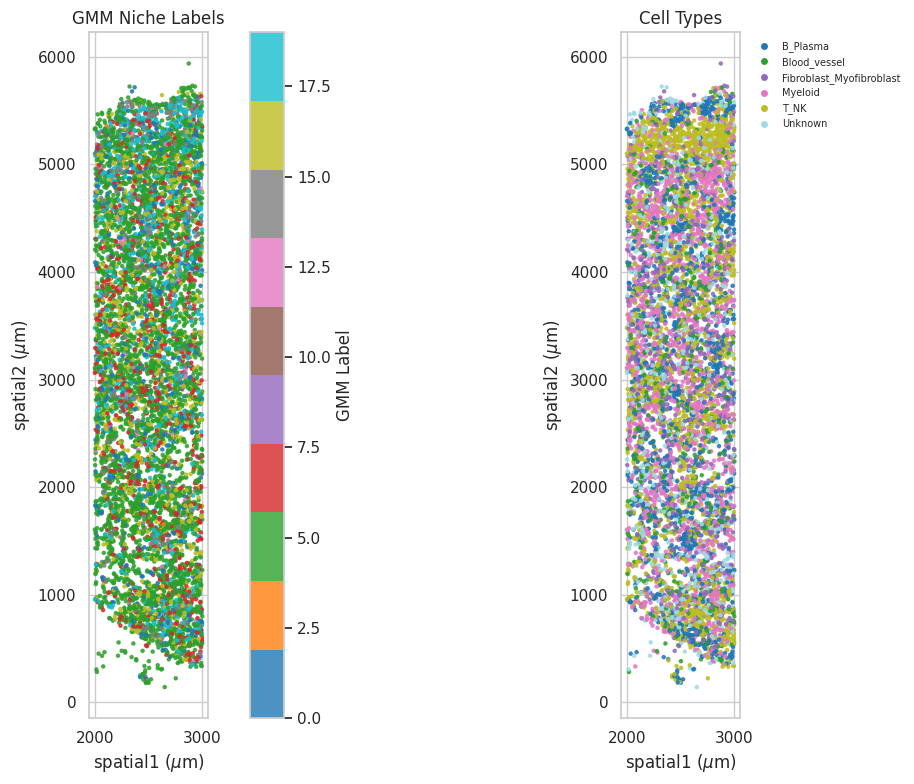

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

labels = Q.argmax(axis=1)
unique_labels = np.unique(labels)
coords = adata.obsm["spatial"]
cell_types = adata.obs["final_label"].values
unique_types = np.unique(cell_types)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))


cmap_labels = plt.cm.get_cmap("tab10", len(unique_labels))
scatter1 = axes[0].scatter(coords[:, 0], coords[:, 1], c=labels, cmap="tab10", s=5, alpha=0.8)
plt.colorbar(scatter1, ax=axes[0], label="GMM Label")
axes[0].set_title("GMM Niche Labels")
axes[0].set_aspect("equal")

cmap_types = plt.cm.get_cmap("tab20", len(unique_types))
type_to_idx = {t: i for i, t in enumerate(unique_types)}
type_indices = [type_to_idx[t] for t in cell_types]
type_indices = np.array(type_indices)

scatter2 = axes[1].scatter(coords[:, 0], coords[:, 1],c=type_indices, cmap="tab20", s=5, alpha=0.8)
axes[1].set_title("Cell Types")
axes[1].set_aspect("equal")

handles = [plt.Line2D([0], [0], marker="o", color="w", markerfacecolor=cmap_types(type_to_idx[t]), markersize=6, label=t) for t in unique_types]
axes[1].legend(handles=handles, bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=7, frameon=False)

for ax in axes:
  ax.set_xlabel("spatial1 ($\mu$m)")
  ax.set_ylabel("spatial2 ($\mu$m)")

plt.tight_layout()
plt.show()

In [ ]:
import math
from scipy.special import logsumexp
from scipy.stats import multivariate_normal


neighbour_weights = {}
for (i, j), w in zip(edges, edge_weights):
  if i not in neighbour_weights:
    neighbour_weights[i] = []
  if j not in neighbour_weights:
    neighbour_weights[j] = []

  neighbour_weights[i].append((j, w))
  neighbour_weights[j].append((i, w))


def gaussian_log_likelihood(X, means, covs):
  n, K = X.shape[0], means.shape[0]
  log_likelihood = np.zeros((n, K))
  for k in range(K):
    log_likelihood[:, k] = multivariate_normal.logpdf(X, mean=means[k], cov=covs[k],
                                                  allow_singular=True)
  return log_likelihood

eta = 20
max_iterations = 50
conv_thresh = 1e-5

means = gmm.means_.copy()
covs = gmm.covariances_.copy()
log_pi = np.log(gmm.weights_ + 1e-99)

for em_iter in range(max_iterations):
  Q_old = Q.copy()

  # E-step
  log_likelihood = gaussian_log_likelihood(X_pca, means, covs)

  P = np.zeros((n_nodes, K))
  for i, neighbours in neighbour_weights.items():
    if not neighbours:
        continue
    js = np.array([j for j, _ in neighbours])
    ws = np.array([w for _, w in neighbours])
    P[i] = eta * (ws[:, None] * Q[js]).sum(axis=0)

  log_Q_unnorm = log_likelihood + log_pi[None, :] + P
  log_Z = logsumexp(log_Q_unnorm, axis=1, keepdims=True)
  Q = np.exp(log_Q_unnorm - log_Z)

  # M-step
  N_k = Q.sum(axis=0) + 1e-300
  log_pi = np.log(N_k / N_k.sum())

  means = np.matmul(Q.T, X_pca) / N_k[:, None]

  for k in range(K):
      diff = X_pca - means[k]
      covs[k] = np.matmul((Q[:, k:k+1] * diff).T, diff) / N_k[k]
      covs[k] += 1e-6 * np.eye(X_pca.shape[1])

  delta    = np.abs(Q - Q_old).max()
  entropy  = -np.sum(Q * np.log(Q + 1e-300), axis=1).mean()
  labels   = Q.argmax(axis=1)
  sizes    = np.bincount(labels, minlength=K)
  print(f"iteration {em_iter+1}, change={delta:.5f}, entropy={entropy:.3f}, sizes={sizes}")
  if delta < conv_thresh:
    print("Converged.")
    break

print(f"Active columns: {np.where(Q.mean(axis=0) > 0.01)[0]}")

adata.obs["niche_mrf"]   = labels
adata.obsm["niche_mrf_soft"] = Q

print("Done")

iteration 1, change=1.00000, entropy=0.033, sizes=[ 267  381    7    1 2785  814  545  374    5    1   15    5    2   63
    4  429  161  646  892  356]
iteration 2, change=1.00000, entropy=0.022, sizes=[ 270  354    7    1 2624  919  589  329    5    1   15    5    2   61
    4  379  138  637  998  415]
iteration 3, change=1.00000, entropy=0.018, sizes=[ 269  334    7    1 2541  989  618  305    5    1   15    5    2   59
    4  356  140  613 1043  446]
iteration 4, change=1.00000, entropy=0.014, sizes=[ 278  316    7    1 2481 1035  628  273    5    1   15    5    2   56
    4  343  136  614 1088  465]
iteration 5, change=1.00000, entropy=0.013, sizes=[ 280  304    7    1 2467 1054  638  260    5    1   15    5    2   54
    4  334  131  613 1105  473]
iteration 6, change=1.00000, entropy=0.012, sizes=[ 279  297    7    1 2451 1081  639  247    5    1   15    5    2   52
    4  324  130  606 1122  485]
iteration 7, change=1.00000, entropy=0.011, sizes=[ 279  294    7    1 2434 1088  

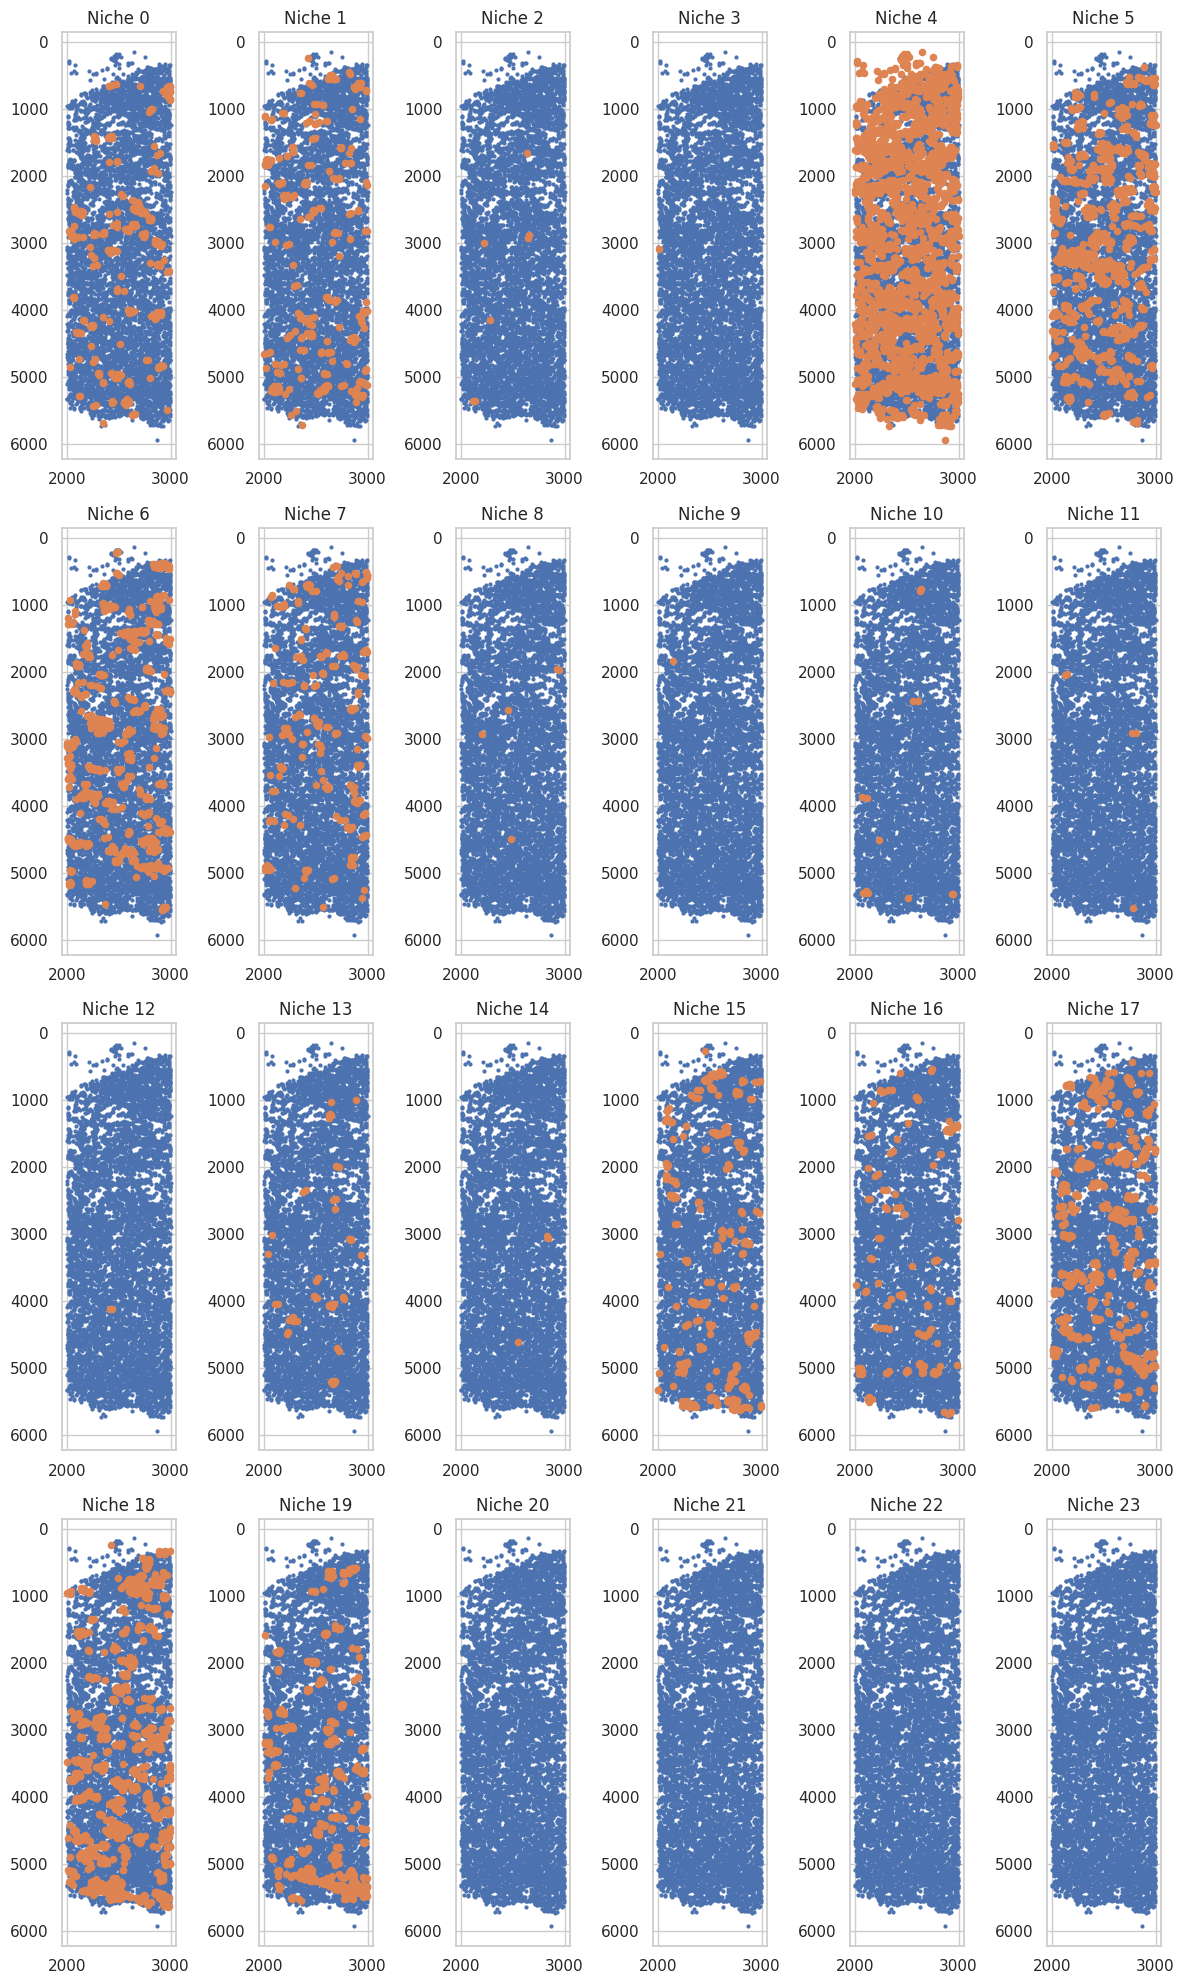

In [ ]:
import math

coords = adata.obsm["spatial"]
labels = adata.obs["niche_mrf"].values
niche_labels = adata.obs["niche_mrf"].values
unique_niches = np.unique(niche_labels)[:]

n_cols = 6
n_rows = math.ceil(len(unique_niches)/n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(2*n_cols, 5*n_rows))

for i, ax_r in enumerate(axes):
  for j, ax in enumerate(ax_r):
    k = i * n_cols + j
    ax.set_title(f"Niche {k}")

    ax.scatter(coords[:, 0], coords[:, 1], s=4)
    ax.scatter(coords[(niche_labels == k), 0], coords[(niche_labels == k), 1], s=20)

    ax.invert_yaxis()

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import pandas as pd
from scipy import sparse
from scipy.stats import entropy
from collections import defaultdict

Q = adata.obsm["niche_mrf_soft"]
labels = adata.obs["niche_mrf"].astype(int).values
n_nodes, K = Q.shape

A = adata.obsp["spatial_connectivities"].tocsr()

# Step 1
max_prob = Q.max(axis=1)
margin = np.sort(Q, axis=1)[:, -1] - np.sort(Q, axis=1)[:, -2]
q_entropy = entropy(Q.T)

CONF_THRESH  = 0.1
MARGIN_THRESH= 0.10
ENTROPY_MAX  = 2.0
confident = (max_prob >= CONF_THRESH) & (margin >= MARGIN_THRESH) & (q_entropy <= ENTROPY_MAX)

print(f"Confident cells: {confident.sum()}/{n_nodes}  ")

# Step 2

MIN_FRACTION = 0.01
MIN_SIZE  = 10

def bfs_CC(mask, adj):
  nodes = np.where(mask)[0]
  node_set = set(nodes.tolist())
  components = np.full(adj.shape[0], -1, dtype=int)
  comp_id = 0
  visited = set()
  for start in nodes:
    if start in visited:
      continue
    queue = [start]
    while queue:
      n = queue.pop(0)
      if n in visited:
        continue
      visited.add(n)
      components[n] = comp_id
      for nb in adj.indices[adj.indptr[n]:adj.indptr[n+1]]:
        if nb in node_set and nb not in visited:
          queue.append(nb)
    comp_id += 1
  return components

clean_labels = np.full(n_nodes, -1, dtype=int)

for k in range(K):
  k_subgraph = (labels == k) & confident
  if k_subgraph.sum() == 0:
    continue

  comp = bfs_CC(k_subgraph, A)
  comp_ids, comp_sizes = np.unique(comp[comp >= 0], return_counts=True)

  cluster_size = k_subgraph.sum()

  for cid, csz in zip(comp_ids, comp_sizes):
    if csz >= max(MIN_SIZE, MIN_FRACTION * cluster_size):
      clean_labels[(comp == cid)] = k

n_assigned = (clean_labels >= 0).sum()
print(f"BFS {n_assigned}/{n_nodes} cells assigned  ")


# Step 3
MAX_FILL_ITERS = 10
MAJORITY_THRESH = 0.60

for fill_iter in range(MAX_FILL_ITERS):
  unassigned = np.where(clean_labels == -1)[0]
  if len(unassigned) == 0:
    break
  changed = False
  for i in unassigned:
    nb_idx = A.indices[A.indptr[i]:A.indptr[i+1]]
    nb_labels = clean_labels[nb_idx]
    assigned_nb = nb_labels[nb_labels >= 0]
    if len(assigned_nb) == 0:
      continue
    vals, counts = np.unique(assigned_nb, return_counts=True)
    best_label = vals[counts.argmax()]
    if counts.max() / len(nb_idx) >= MAJORITY_THRESH:
      clean_labels[i] = best_label
      changed = True

  if changed:
    break


# Step 4
MIN_SIZE = 5

final_ids, final_sizes = np.unique(clean_labels[clean_labels >= 0], return_counts=True)
small_clusters = final_ids[final_sizes < MIN_SIZE]
for sc in small_clusters:
    clean_labels[clean_labels == sc] = -1

# End
surviving = np.array(sorted(set(clean_labels[clean_labels >= 0]),
                             key=lambda k: -(clean_labels == k).sum()))
remap = {old: new for new, old in enumerate(surviving)}
final_labels = np.where(clean_labels >= 0, np.vectorize(remap.get)(clean_labels, -1), -1)

adata.obs["niche_clean"] = final_labels.astype(str)
adata.obs["niche_clean_int"] = final_labels

print(f"{'Niche':>6}  {'Cells':>6}  {'MeanConf':>9}  {'MeanEntropy':>12}")
for niche_id in sorted(set(final_labels)):
    mask = final_labels == niche_id
    label = "none" if niche_id == -1 else str(niche_id)
    mc = max_prob[mask].mean()
    me = q_entropy[mask].mean()
    print(f"{label:>6}  {mask.sum():>6}  {mc:>9.3f}  {me:>12.3f}")

Confident cells: 7748/7753  
BFS 3009/7753 cells assigned  
 Niche   Cells   MeanConf   MeanEntropy
  none    4339      0.996         0.010
     0     894      0.997         0.006
     1     701      0.998         0.006
     2     659      0.999         0.002
     3     384      0.999         0.004
     4     240      0.998         0.005
     5     205      0.996         0.008
     6     109      0.994         0.014
     7     108      0.997         0.010
     8      85      0.994         0.018
     9      16      1.000         0.001
    10      13      1.000         0.001


<>:26: SyntaxWarning: invalid escape sequence '\m'
<>:26: SyntaxWarning: invalid escape sequence '\m'
<>:26: SyntaxWarning: invalid escape sequence '\m'
<>:26: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_4976/3485124549.py:26: SyntaxWarning: invalid escape sequence '\m'
  ax.set_xlabel("spatial1 ($\mu$m)"); ax.set_ylabel("spatial2 ($\mu$m)")
/tmp/ipykernel_4976/3485124549.py:26: SyntaxWarning: invalid escape sequence '\m'
  ax.set_xlabel("spatial1 ($\mu$m)"); ax.set_ylabel("spatial2 ($\mu$m)")


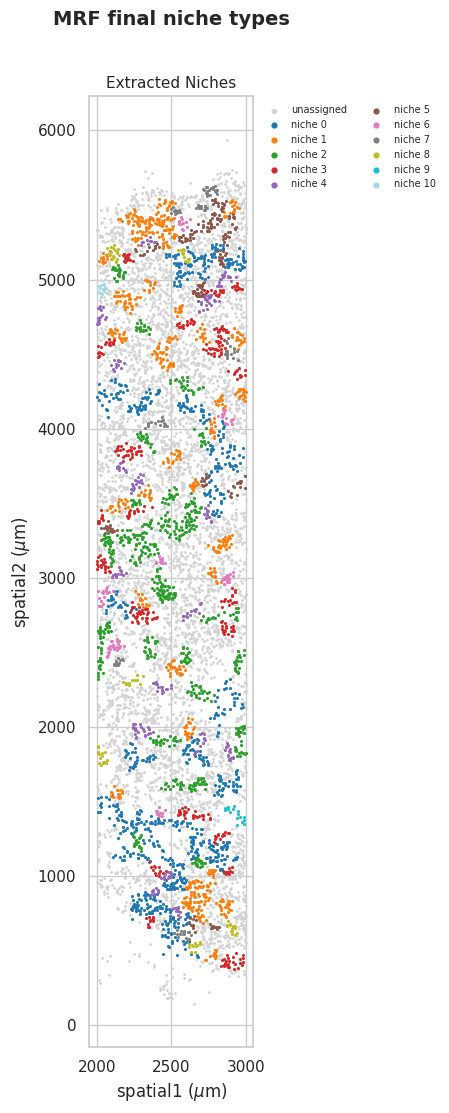

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

coords = adata.obsm["spatial"]
final_labels = adata.obs["niche_clean_int"].values
Q = adata.obsm["niche_mrf_soft"]
max_prob = Q.max(axis=1)

niches = sorted(i for i in np.unique(final_labels) if i >= 0)
num_niches = len(niches)

cmap_cat  = plt.get_cmap("tab20", max(num_niches, 1))
niche_colors = {n: cmap_cat(i) for i, n in enumerate(niches)}
cell_colors = [ niche_colors.get(l, (0.88, 0.88, 0.88, 1.0)) for l in final_labels]

fig, ax = plt.subplots(figsize=(14, 11))
fig.suptitle("MRF final niche types", fontsize=14, fontweight="bold", y=1.01)

unassigned = final_labels == -1
ax.scatter(coords[unassigned, 0], coords[unassigned, 1], c="lightgray", s=4, linewidths=0, rasterized=True, label="unassigned")
for niche_id in niches:
  mask = final_labels == niche_id
  ax.scatter(coords[mask, 0], coords[mask, 1], c=[niche_colors[niche_id]], s=5, linewidths=0, rasterized=True, label=f"niche {niche_id}")
ax.set_title("Extracted Niches", fontsize=11)
ax.set_xlabel("spatial1 ($\mu$m)"); ax.set_ylabel("spatial2 ($\mu$m)")
ax.set_aspect("equal")
ax.legend(markerscale=2, fontsize=7, ncol=2, bbox_to_anchor=(1.01, 1), loc="upper left", frameon=False)

plt.tight_layout()
plt.show()

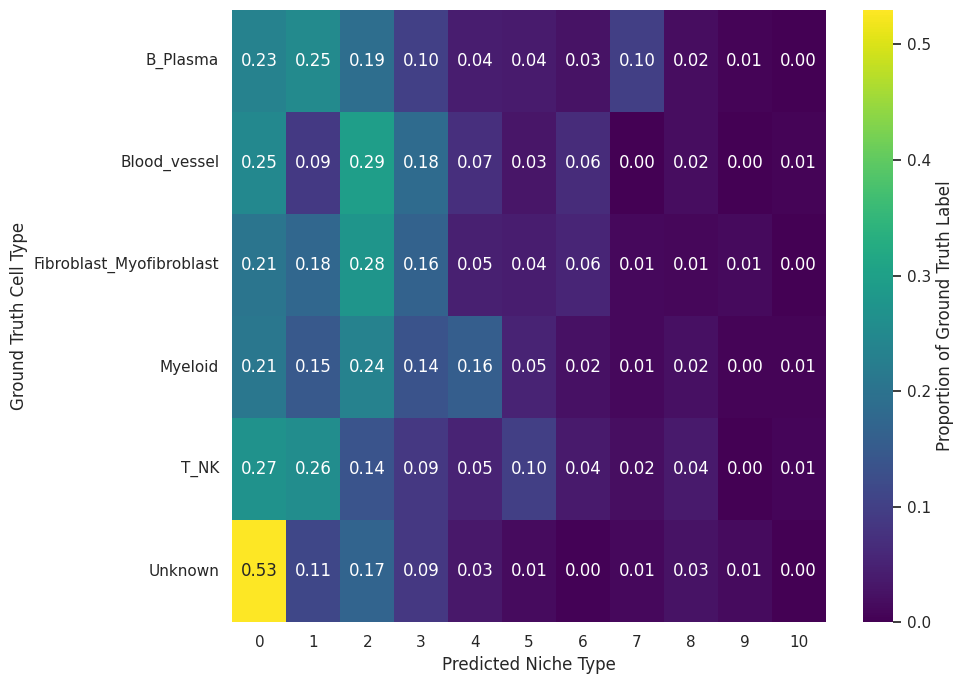

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

ground_truth_labels = adata.obs['final_label']
predicted_niches = adata.obs['niche_clean'].astype(int)

assigned_mask = (predicted_niches != '-1') & (predicted_niches != -1)

table = pd.crosstab(ground_truth_labels[assigned_mask], predicted_niches[assigned_mask], normalize='index')

plt.figure(figsize=(10, 7))
sns.heatmap(
    table,
    annot=True,
    fmt=".2f",
    cmap="viridis",
    cbar_kws={'label': 'Proportion of Ground Truth Label'}
)
plt.xlabel('Predicted Niche Type')
plt.ylabel('Ground Truth Cell Type')
plt.tight_layout()
plt.show()

3
2
0
9
4
8
7
1
6
5
10


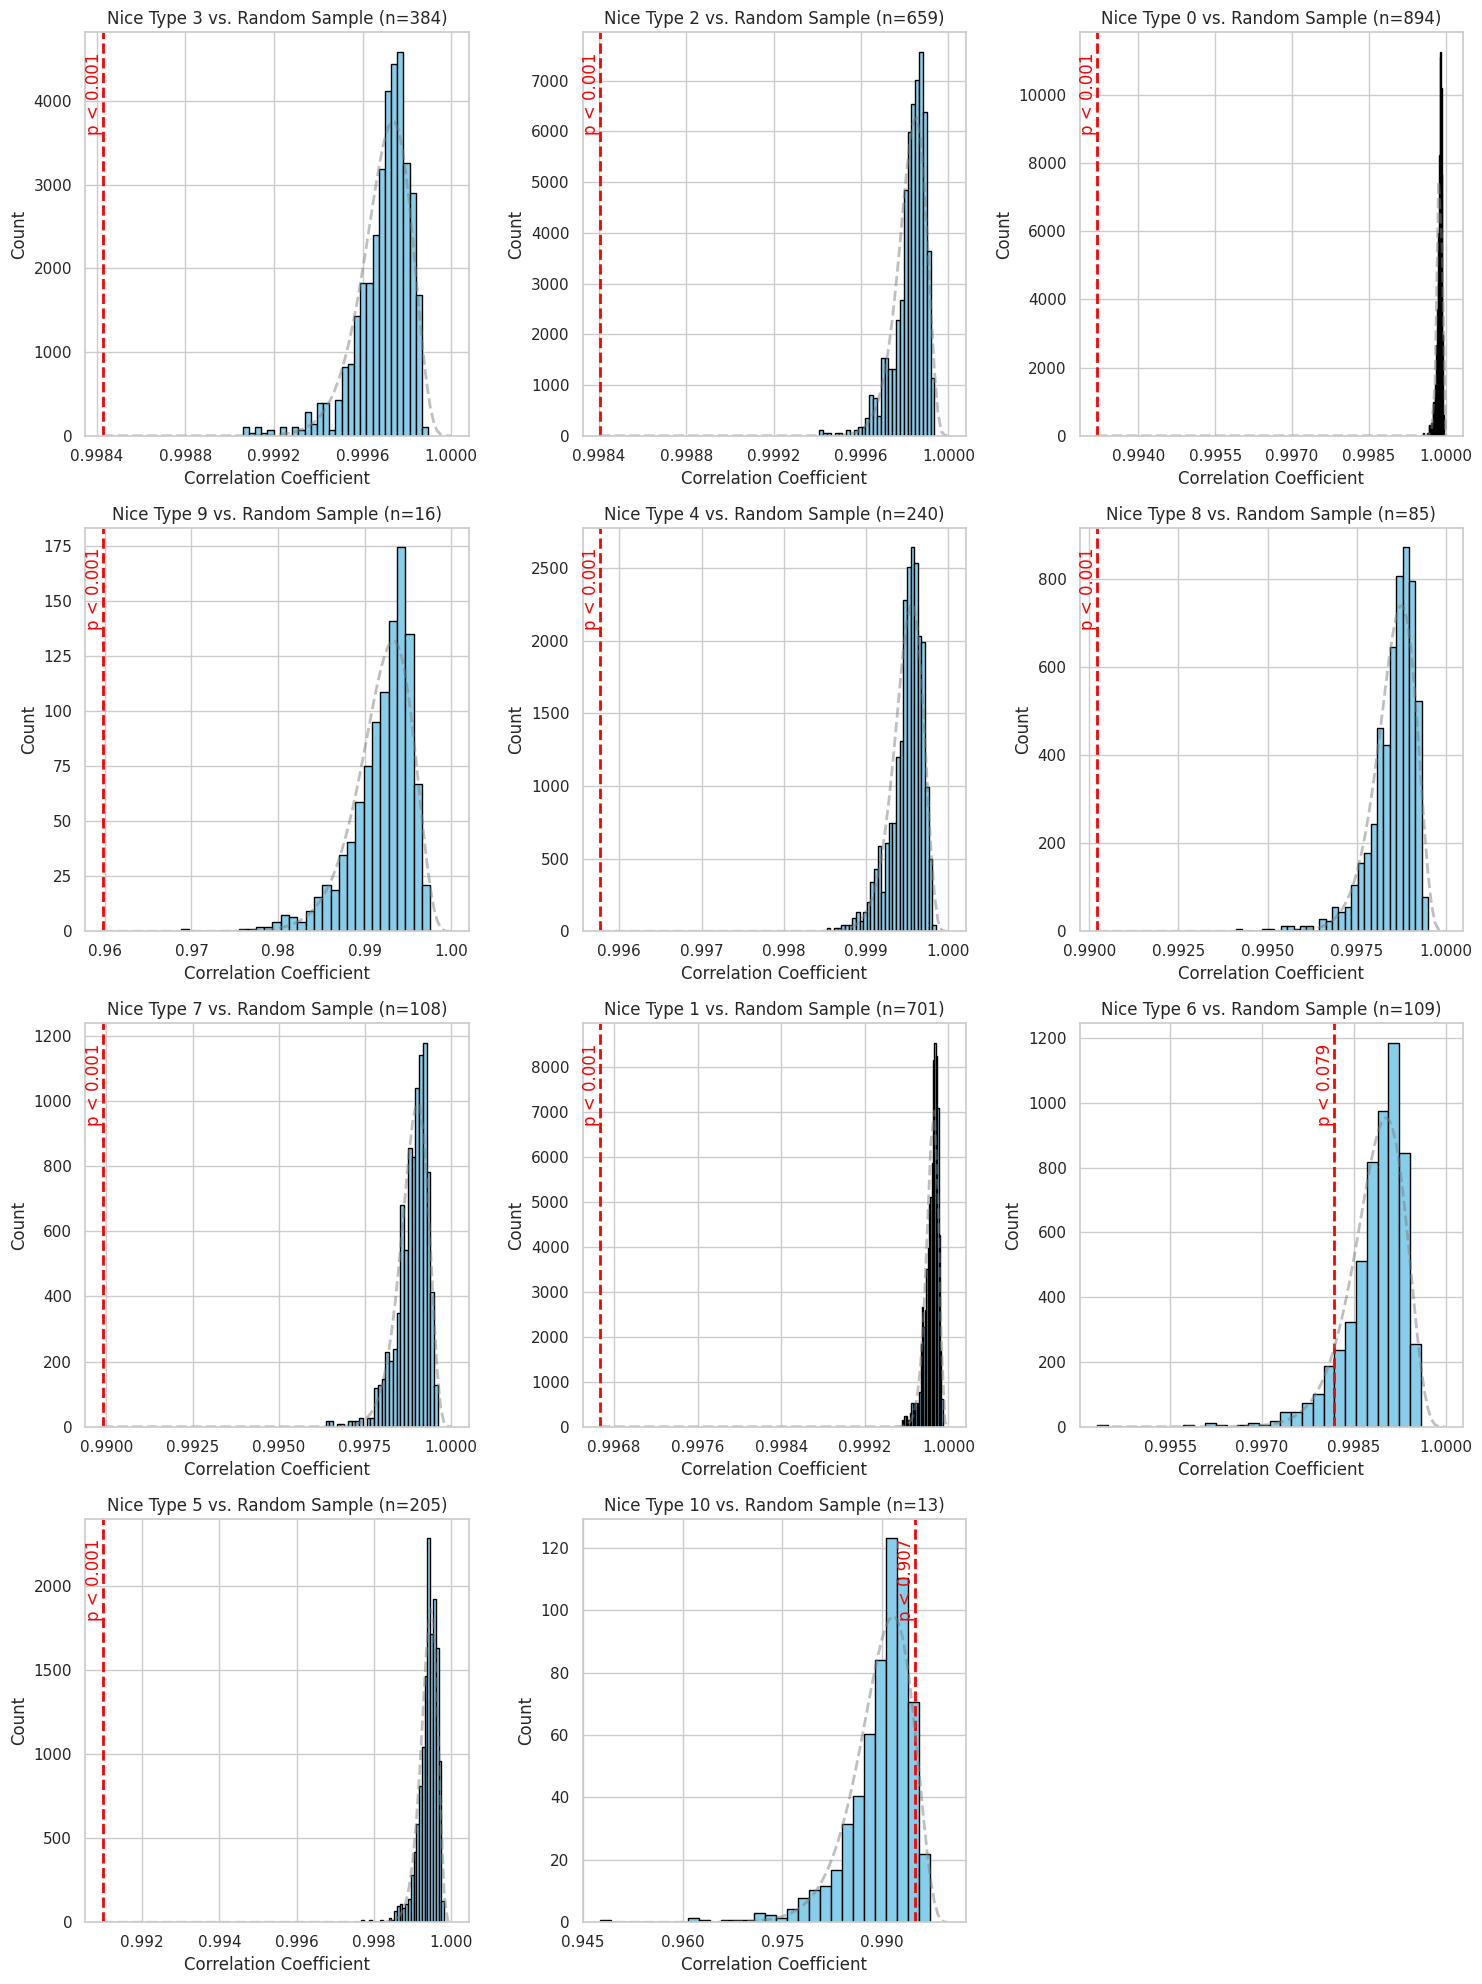

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from scipy.spatial.distance import pdist, squareform
from sklearn.preprocessing import StandardScaler

from scipy.stats import beta as beta_dist

signaling_vectors = pd.DataFrame(adata.obsm['signaling'], index=adata.obs_names)

niche_labels = adata.obs['niche_clean'].astype(str)
unique_labels = niche_labels.unique()
unique_labels = np.delete(unique_labels, np.where(unique_labels == '-1'))
assigned_mask = (niche_labels != '-1')

signaling_df_assigned = signaling_vectors[assigned_mask].copy()
signaling_df_assigned['niche'] = niche_labels[assigned_mask]


dataset_mean = np.mean(adata.obsm['signaling'],axis=0)

n_cols = 3
n_rows = math.ceil((len(unique_labels))/n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 5*n_rows))

for i, ax_r in enumerate(axes):
  for j, ax in enumerate(ax_r):
    if i * n_cols + j >= len(unique_labels):
      ax.remove()
      continue
    label = unique_labels[i * n_cols + j]
    print(label)
    mean_vec = np.mean(adata.obsm['signaling'][niche_labels == label],axis=0)
    count = np.count_nonzero(niche_labels == label)

    score = np.corrcoef(dataset_mean, mean_vec)[0, 1]
    data = []
    rng = np.random.default_rng()
    num_samples = 1000
    for _ in range(num_samples):
      random_niche = rng.choice(adata.obsm['signaling'], size=count, axis=0, replace=False)
      rand_mean_vec = np.mean(random_niche,axis=0)
      data.append(np.corrcoef(dataset_mean, rand_mean_vec)[0, 1])

    ax.hist(data, bins=30, density= True, color='skyblue', edgecolor='black')

    a_fit, b_fit, loc_fit, scale_fit = beta_dist.fit(data, floc=0, fscale=1)

    x = np.linspace(min(min(data),score), 1, 100)
    ax.axvline(score, color='red', linestyle='dashed', linewidth=2, label=f'Mean')
    p_value = math.ceil(beta_dist.cdf(score, a_fit, b_fit, loc_fit, scale_fit) * 1000) / 1000
    ax.text(score, 0.95, f"p < {p_value:0.3f}", transform=ax.get_xaxis_transform(), color='red', ha='right', va='top', rotation=90)

    ax.set_title(f"Nice Type {label} vs. Random Sample (n={count})")
    ax.xaxis.set_major_locator(plt.MaxNLocator(nbins=5))
    plt.xticks(rotation=30, ha='right')
    ax.set_xlabel("Correlation Coefficient")
    ax.set_ylabel("Count")
    ax.plot(x, beta_dist.pdf(x, a_fit, b_fit, loc_fit, scale_fit), lw=2, color='gray', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()
